# Ridge Regression - Precios de Propiedades en CABA

Implementación de regularización Ridge (L2) desde scratch para predecir el precio de propiedades en CABA.
Extiende el modelo de regresión lineal del notebook 04 agregando penalización sobre los pesos.

**Features (X)**: `metros`, `ambientes`, `banos`, `expensas`  
**Target (y)**: `precio` en USD

## Estructura
1. Setup e imports
2. Datos (carga, split, scaling)
3. Ridge desde scratch (`compute_cost_ridge`, `compute_gradient_ridge`, `gradient_descent`)
4. Tuning de λ sobre validation
5. Evaluación (comparación con baseline del notebook 04)

### 1. Setup/Imports

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### 2. Datos

Mismo pipeline que el notebook 04: carga → split 70/15/15 → z-score normalization fitteada sobre train.

In [6]:
df = pd.read_csv("../data/processed/zonaprop_clean.csv")

features = ["metros", "ambientes", "banos", "expensas"]
X = df[features].values
y = df["precio"].values

np.random.seed(42)
idx = np.random.permutation(len(X))
X, y = X[idx], y[idx]
n = len(X)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
X_train, y_train = X[:n_train],              y[:n_train]
X_val,   y_val   = X[n_train:n_train+n_val], y[n_train:n_train+n_val]
X_test,  y_test  = X[n_train+n_val:],        y[n_train+n_val:]

mu    = X_train.mean(axis=0)
sigma = X_train.std(axis=0)
X_train_s = (X_train - mu) / sigma
X_val_s   = (X_val   - mu) / sigma
X_test_s  = (X_test  - mu) / sigma

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")

Train: (22809, 4) | Val: (4887, 4) | Test: (4889, 4)


### 3. Regularización Ridge (L2) desde scratch

La regresión lineal minimiza el error sobre los datos de entrenamiento, pero
nada le impide volverse muy complejo para lograrlo — pesos enormes que se ajustan
perfectamente al train pero fallan en datos nuevos. Eso es **overfitting**.

**Ridge** lo resuelve agregando una penalización al costo proporcional al tamaño de los
pesos. El modelo ya no puede hacer los pesos arbitrariamente grandes sin pagar un precio
en la función de costo:

$$J_{ridge}(\mathbf{w}, b) = \underbrace{\frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2}_{\text{error}} + \underbrace{\frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2}_{\text{penalización}}$$

El parámetro **λ (lambda)** controla el balance entre los dos términos:

- λ = 0 → sin regularización, idéntico a regresión lineal
- λ grande → pesos forzados a acercarse a cero, modelo más simple (riesgo de underfitting)
- λ chico → penalización suave, se parece a sin regularización

> `b` no se regulariza. La convención estándar es penalizar solo los pesos $\mathbf{w}$,
> porque `b` controla el nivel base de la predicción, no la complejidad del modelo.

Al derivar la función de costo modificada, solo cambia el gradiente de $\mathbf{w}$ —
se le suma el término de penalización. El gradiente de `b` queda igual:

$$\frac{\partial J_{ridge}}{\partial \mathbf{w}} = \frac{1}{m} \mathbf{X}^T (\hat{y} - y) + \frac{\lambda}{m} \mathbf{w} \qquad \frac{\partial J_{ridge}}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

#### 3.1 `compute_cost_ridge`

In [7]:
def compute_cost_ridge(X, y, w, b, lambda_):
    m = X.shape[0]
    y_hat = X @ w + b
    cost = (1 / (2 * m)) * np.sum((y_hat - y) ** 2)
    penalty = (lambda_ / (2 * m)) * np.sum(w ** 2)
    return cost + penalty

#### 3.2 `compute_gradient_ridge`

In [8]:
def compute_gradient_ridge(X, y, w, b, lambda_):
    m = len(y)
    y_hat = X @ w + b
    error = y_hat - y
    dw = (1 / m) * X.T @ error + (lambda_ / m) * w
    db = (1 / m) * np.sum(error)
    return dw, db

#### 3.3 `gradient_descent` con Ridge

In [9]:
def gradient_descent_ridge(X, y, w_init, b_init, alpha, num_iters, lambda_, X_val, y_val):
    """
    Runs gradient descent with Ridge (L2) regularization.

    Args:
        X        (ndarray): training data, shape (m, n)
        y        (ndarray): target values, shape (m,)
        w_init   (ndarray): initial weights, shape (n,)
        b_init   (float):   initial bias
        alpha    (float):   learning rate
        num_iters (int):    number of iterations
        lambda_  (float):   regularization strength
        X_val    (ndarray): validation data, shape (m_val, n)
        y_val    (ndarray): validation targets, shape (m_val,)

    Returns:
        w                  (ndarray): optimized weights
        b                  (float):   optimized bias
        train_cost_history (list):    train cost every 100 iterations
        val_cost_history   (list):    val cost every 100 iterations
    """
    w = w_init.copy()
    b = b_init
    train_cost_history = []
    val_cost_history = []

    for i in range(num_iters):
        dw, db = compute_gradient_ridge(X, y, w, b, lambda_)
        w = w - alpha * dw
        b = b - alpha * db

        if i % 100 == 0:
            train_cost_history.append(compute_cost_ridge(X, y, w, b, lambda_))
            val_cost_history.append(compute_cost_ridge(X_val, y_val, w, b, lambda_))

    return w, b, train_cost_history, val_cost_history

In [10]:
w_init = np.zeros(X_train_s.shape[1])
b_init = 0.0
alpha = 0.1
num_iters = 1000
lambda_ = 1.0

w_r, b_r, train_cost_history, val_cost_history = gradient_descent_ridge(
    X_train_s, y_train, w_init, b_init, alpha, num_iters, lambda_, X_val_s, y_val
)

print("Evolución del costo (λ=1.0):")
for i, (tc, vc) in enumerate(zip(train_cost_history, val_cost_history)):
    print(f"  iter {i * 100:>5}: train={tc:>22,.2f}  val={vc:>22,.2f}")

Evolución del costo (λ=1.0):
  iter     0: train=     57,434,366,277.61  val=     57,409,379,160.12
  iter   100: train=     15,179,070,294.53  val=     14,811,311,315.85
  iter   200: train=     15,165,030,191.10  val=     14,756,887,274.04
  iter   300: train=     15,164,922,307.12  val=     14,753,199,474.88
  iter   400: train=     15,164,921,466.96  val=     14,752,882,596.18
  iter   500: train=     15,164,921,460.41  val=     14,752,854,692.15
  iter   600: train=     15,164,921,460.36  val=     14,752,852,229.29
  iter   700: train=     15,164,921,460.36  val=     14,752,852,011.86
  iter   800: train=     15,164,921,460.36  val=     14,752,851,992.67
  iter   900: train=     15,164,921,460.36  val=     14,752,851,990.97


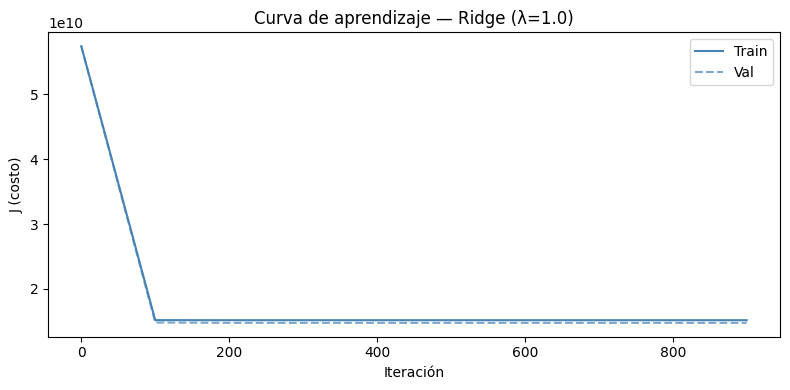

In [11]:
iters = [i * 100 for i in range(len(train_cost_history))]

plt.figure(figsize=(8, 4))
plt.plot(iters, train_cost_history, color="steelblue", label="Train")
plt.plot(iters, val_cost_history, color="steelblue", linestyle="--", alpha=0.7, label="Val")
plt.xlabel("Iteración")
plt.ylabel("J (costo)")
plt.title("Curva de aprendizaje — Ridge (λ=1.0)")
plt.legend()
plt.tight_layout()
plt.show()

### 4. Tuning de λ

In [ ]:
lambdas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
results = []

for lam in lambdas:
    w_l, b_l, _, val_hist = gradient_descent_ridge(
        X_train_s, y_train, np.zeros(X_train_s.shape[1]), 0.0,
        alpha, num_iters, lam, X_val_s, y_val
    )
    val_cost = val_hist[-1]
    results.append({"lambda": lam, "val_cost": val_cost, "w": w_l, "b": b_l})
    print(f"λ={lam:<8}  val_cost={val_cost:>25,.2f}")

best = min(results, key=lambda r: r["val_cost"])
print(f"\nMejor λ: {best['lambda']}")

In [ ]:
val_costs = [r["val_cost"] for r in results]

plt.figure(figsize=(8, 4))
plt.plot(lambdas, val_costs, color="steelblue", marker="o")
plt.xscale("log")
plt.xlabel("λ (escala logarítmica)")
plt.ylabel("Val cost")
plt.title("Tuning de λ — val cost por valor de regularización")
plt.axvline(best["lambda"], color="steelblue", linestyle="--", alpha=0.5, label=f"λ óptimo = {best['lambda']}")
plt.legend()
plt.tight_layout()
plt.show()

### 5. Evaluación

Entrenamos el modelo final con el mejor λ y comparamos contra el baseline de regresión lineal (notebook 04).

In [17]:
def evaluate(X, y, w, b):
    y_hat = X @ w + b
    errors = y_hat - y
    mse  = np.mean(errors ** 2)
    rmse = np.sqrt(mse)
    mae  = np.mean(np.abs(errors))
    r2   = 1 - np.sum(errors ** 2) / np.sum((y - y.mean()) ** 2)
    return {"MSE": mse, "RMSE": rmse, "MAE": mae, "R²": r2}

w_best, b_best = best["w"], best["b"]

print(f"{'':6} {'RMSE':>12}  {'MAE':>12}  {'R²':>6}")
print("-" * 42)
sets = {"Train": (X_train_s, y_train), "Val": (X_val_s, y_val), "Test": (X_test_s, y_test)}
for name, (X_s, y_s) in sets.items():
    m = evaluate(X_s, y_s, w_best, b_best)
    print(f"{name:6} {m['RMSE']:>12,.0f}  {m['MAE']:>12,.0f}  {m['R²']:>6.4f}")


               RMSE           MAE      R²
------------------------------------------
Train       174,151        98,390  0.5500
Val         171,753        96,885  0.5546
Test        167,361        96,184  0.5379
